# *De Novo* Peptide Sequencing Database Explorer

This notebook inspects the contents of `denovo.db` and creates visualizations of the relationships between authors, methods, publications, and affiliations across the *de novo* peptide sequencing field.

**Scope**: comprehensive — both deep-learning and classical methods, plus post-processors, downstream applications, and adjacent tools (DB-search hybrids, glycopeptide pipelines).

Every `algorithm` row carries three classifier columns we exploit below:

- **`kind`** — `'algorithm'`, `'post-processor'`, `'downstream-application'`, `'adjacent'`, or `'meta'`
- **`is_deep_learning`** — `1` / `0` / `NULL`
- **`acquisition_mode`** — `'DDA'`, `'DIA'`, `'both'`, or `NULL`

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
conn = sqlite3.connect("denovo.db")

## 1. Database Overview

In [2]:
tables = ["algorithm", "publication", "author", "affiliation", "country", "city",
          "author_affiliation", "publication_author", "publication_algorithm"]

for t in tables:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn).iloc[0, 0]
    print(f"{t:30s} {n:>5d} rows")

algorithm                         68 rows
publication                       73 rows
author                           301 rows
affiliation                      133 rows
country                           17 rows
city                              60 rows
author_affiliation               399 rows
publication_author               479 rows
publication_algorithm             74 rows


## 2. All Algorithms

In [3]:
df_alg = pd.read_sql(
    """
    SELECT name, algorithm_family AS family, kind,
           CASE WHEN is_deep_learning = 1 THEN 'DL'
                WHEN is_deep_learning = 0 THEN 'classical'
                ELSE NULL END AS approach,
           acquisition_mode AS acquisition,
           short_description, repository
    FROM algorithm
    ORDER BY name
    """,
    conn,
)
df_alg

,name,family,kind,approach,acquisition,short_description,repository
0,AdaNovo,Transformer (AR),algorithm,DL,DDA,Mutual info for PTMs,NaN
1,BiATNovo,Transformer (AR),algorithm,DL,DDA,Bidirectional self-attention,NaN
2,Casanovo,Transformer (AR),algorithm,DL,DDA,First Transformer,https://github.com/Noble-Lab/casanovo
3,Casanovo-DB,Transformer (AR),adjacent,DL,DDA,Database search scoring,NaN
4,Cascadia,Transformer (AR),algorithm,DL,DIA,Transformer for DIA,NaN
...,...,...,...,...,...,...,...
63,pNovo+,Graph / DP,algorithm,classical,DDA,Complementary HCD + ETD spectra,NaN
64,pXg,NaN,downstream-application,classical,DDA,MHC-I noncanonical peptides,https://github.com/progistar/pXg
65,π-HelixNovo,Transformer (AR),algorithm,DL,DDA,Complementary spectra,https://github.com/PHOENIXcenter/pi-HelixNovo
66,π-PrimeNovo,Transformer (NAR),algorithm,DL,DDA,NAR Transformer (CTC),https://github.com/BEAM-Labs/denovo/tree/main/...


## 2a. Methods by kind

Five paper kinds in this catalog. The bulk are core *de novo* **algorithms**; the rest are post-processors / re-rankers, downstream applications (immunopeptidomics, metaproteomics, neoantigen pipelines), adjacent tools (DB-search hybrids, glycopeptide), and meta papers (reviews, theses).

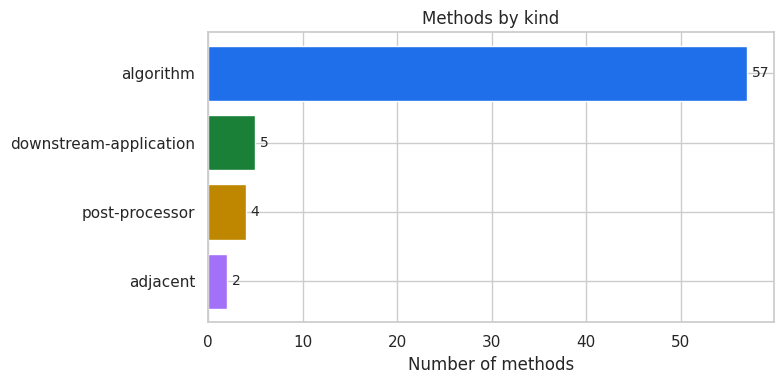

In [4]:
# Methods by kind
kind_counts = df_alg["kind"].value_counts()
kind_palette = {
    "algorithm":              "#1f6feb",
    "post-processor":         "#bf8700",
    "downstream-application": "#1a7f37",
    "adjacent":               "#a371f7",
    "meta":                   "#8c959f",
}
fig, ax = plt.subplots(figsize=(8, 4))
colors = [kind_palette.get(k, "#8c959f") for k in kind_counts.index]
bars = ax.barh(kind_counts.index[::-1], kind_counts.values[::-1], color=colors[::-1], edgecolor="white")
for bar, n in zip(bars, kind_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{n}", va="center", fontsize=10)
ax.set_xlabel("Number of methods")
ax.set_title("Methods by kind")
plt.tight_layout()
plt.show()

## 2b. Deep learning vs. classical

Each method is flagged `is_deep_learning = 0/1`. Cross-tabulating with `kind` shows where deep learning has displaced classical approaches and where classical methods (e.g. graph-based, HMM, decision-tree, learning-to-rank) still occupy the field.

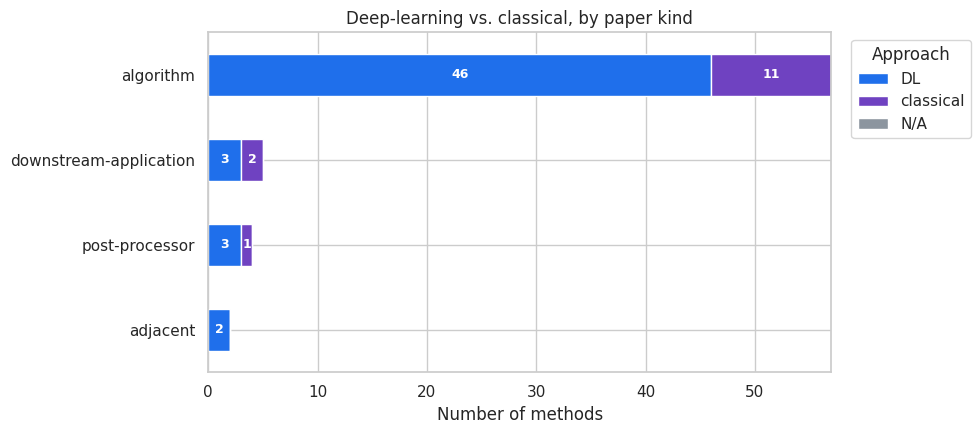


Totals — DL: 54  ·  classical: 14  ·  N/A: 0


In [5]:
# Deep-learning vs. classical, broken down by kind
dl_by_kind = (
    df_alg.assign(approach=df_alg["approach"].fillna("N/A"))
          .groupby(["kind", "approach"]).size().unstack(fill_value=0)
)
# Stable column order
for col in ("DL", "classical", "N/A"):
    if col not in dl_by_kind.columns:
        dl_by_kind[col] = 0
dl_by_kind = dl_by_kind[["DL", "classical", "N/A"]]

# Sort kinds by total descending
dl_by_kind = dl_by_kind.loc[dl_by_kind.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(10, 4.5))
dl_by_kind.plot(
    kind="barh", stacked=True, ax=ax,
    color={"DL": "#1f6feb", "classical": "#6f42c1", "N/A": "#8c959f"},
    edgecolor="white",
)
ax.set_xlabel("Number of methods")
ax.set_ylabel("")
ax.set_title("Deep-learning vs. classical, by paper kind")
ax.legend(title="Approach", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    for bar in container:
        w = bar.get_width()
        if w > 0:
            ax.text(bar.get_x() + w / 2, bar.get_y() + bar.get_height() / 2,
                    int(w), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nTotals — DL: {int(dl_by_kind['DL'].sum())}  ·  "
      f"classical: {int(dl_by_kind['classical'].sum())}  ·  "
      f"N/A: {int(dl_by_kind['N/A'].sum())}")

## 2c. Methods by acquisition mode

How many methods target DDA (data-dependent) vs. DIA (data-independent) acquisition, and how many work across both. NULL = not applicable (e.g. a re-ranker that doesn't care).

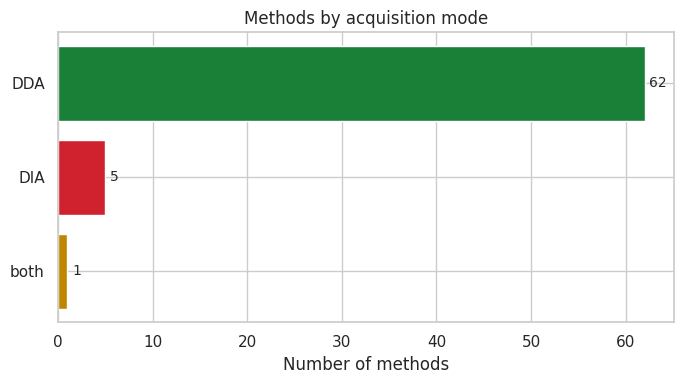

In [6]:
# Acquisition modes (DDA / DIA / both / N/A)
acq_counts = df_alg["acquisition"].fillna("N/A").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
acq_palette = {"DDA": "#1a7f37", "DIA": "#cf222e", "both": "#bf8700", "N/A": "#8c959f"}
colors = [acq_palette.get(label, "#8c959f") for label in acq_counts.index]
bars = ax.barh(acq_counts.index[::-1], acq_counts.values[::-1], color=colors[::-1], edgecolor="white")
for bar, n in zip(bars, acq_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{n}", va="center", fontsize=10)
ax.set_xlabel("Number of methods")
ax.set_title("Methods by acquisition mode")
plt.tight_layout()
plt.show()

## 3. Publications

In [7]:
df_pub = pd.read_sql(
    "SELECT id, title, publication_date, publication_type, doi, publisher FROM publication ORDER BY publication_date",
    conn,
    parse_dates=["publication_date"],
)
df_pub

,id,title,publication_date,publication_type,doi,publisher
0,65,Sequence database searches via de novo peptide...,1997-09-01,peer-reviewed,NaN,Wiley
1,66,De novo peptide sequencing via tandem mass spe...,1999-01-01,peer-reviewed,10.1089/106652799318300,Mary Ann Liebert
2,67,PEAKS: powerful software for peptide de novo s...,2003-10-15,peer-reviewed,10.1002/rcm.1196,Wiley
3,68,PepNovo: de novo peptide sequencing via probab...,2005-02-15,peer-reviewed,10.1021/ac048788h,American Chemical Society
4,69,NovoHMM: A Hidden Markov Model for de Novo Pep...,2005-11-15,peer-reviewed,10.1021/ac0508853,American Chemical Society
...,...,...,...,...,...,...
68,10,Modanovo: A Unified Model for Post-Translation...,2025-09-16,preprint,10.1101/2025.09.12.675784,bioRxiv
69,9,Bidirectional Representations Augmented Autore...,2025-10-17,preprint,10.48550/arXiv.2510.08169,arXiv
70,8,Accurate de novo sequencing of the modified pr...,2025-12-13,preprint,10.48550/arXiv.2512.12272,arXiv
71,64,CausalNovo: Advancing De Novo Peptide Sequenci...,2026-02-14,preprint,NaN,OpenReview


## 4. Publications Timeline

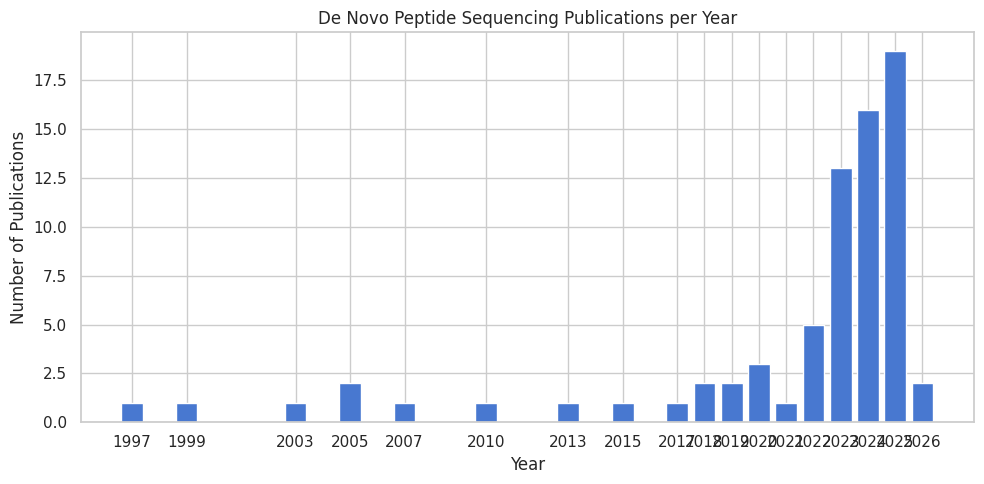

In [8]:
df_timeline = df_pub.dropna(subset=["publication_date"]).copy()
df_timeline["year"] = df_timeline["publication_date"].dt.year
year_counts = df_timeline["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(year_counts.index, year_counts.values, color=sns.color_palette()[0], edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Publications")
ax.set_title("De Novo Peptide Sequencing Publications per Year")
ax.set_xticks(year_counts.index)
plt.tight_layout()
plt.savefig("plots/publications_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Publication Types

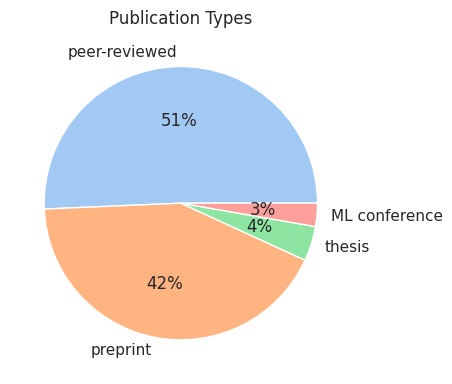

In [9]:
type_counts = df_pub["publication_type"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(type_counts.values, labels=type_counts.index, autopct="%1.0f%%",
       colors=sns.color_palette("pastel"))
ax.set_title("Publication Types")
plt.tight_layout()
plt.savefig("plots/publication_types.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Top Authors by Number of Publications

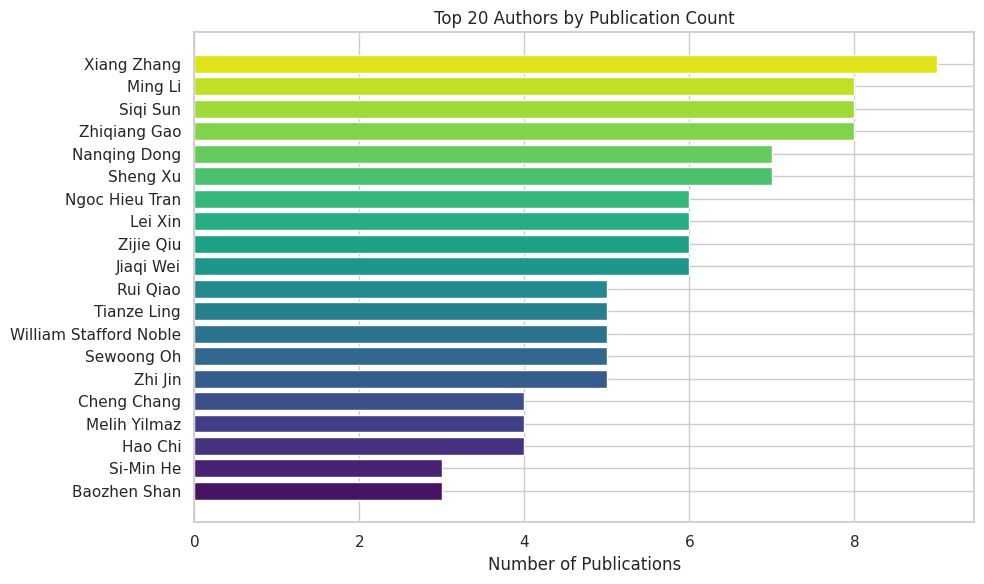

In [10]:
df_top_authors = pd.read_sql("""
    SELECT a.name, COUNT(pa.publication_id) as num_publications
    FROM author a
    JOIN publication_author pa ON a.id = pa.author_id
    GROUP BY a.id
    ORDER BY num_publications DESC
    LIMIT 20
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_top_authors["name"][::-1], df_top_authors["num_publications"][::-1],
        color=sns.color_palette("viridis", len(df_top_authors)))
ax.set_xlabel("Number of Publications")
ax.set_title("Top 20 Authors by Publication Count")
plt.tight_layout()
plt.savefig("plots/top_authors.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Geographic Distribution of Affiliations

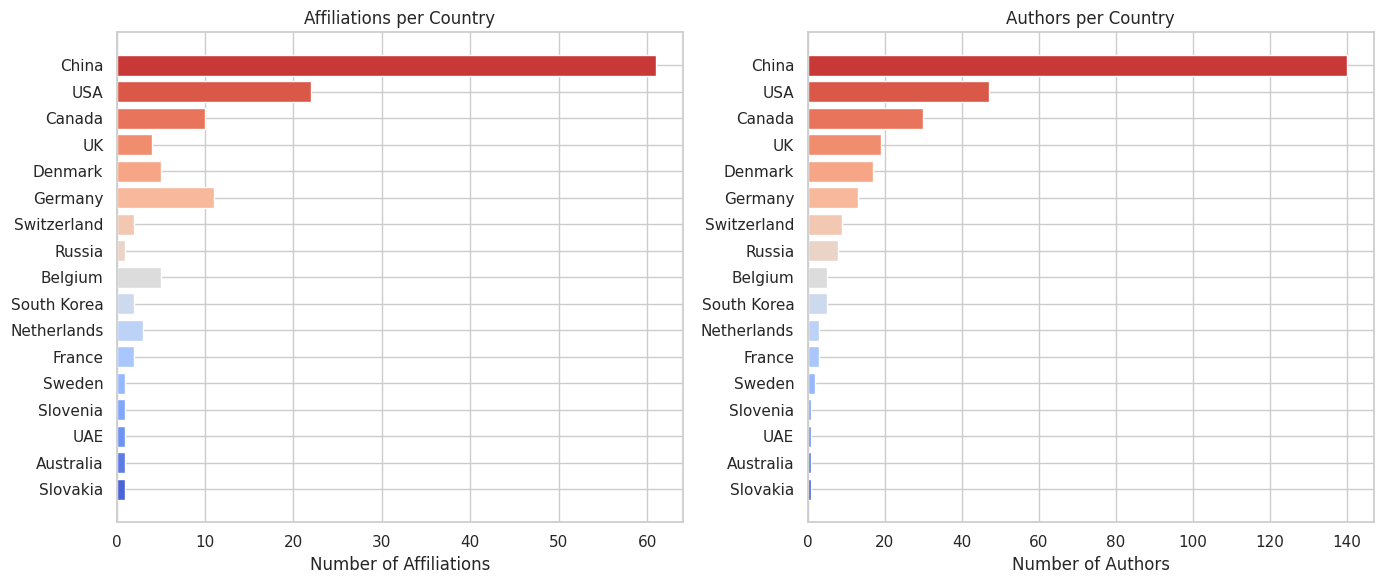

,country,num_affiliations,num_authors
0,China,61,140
1,USA,22,47
2,Canada,10,30
3,UK,4,19
4,Denmark,5,17
5,Germany,11,13
6,Switzerland,2,9
7,Russia,1,8
8,Belgium,5,5
9,South Korea,2,5


In [11]:
df_geo = pd.read_sql("""
    SELECT c.name as country, COUNT(DISTINCT af.id) as num_affiliations,
           COUNT(DISTINCT aa.author_id) as num_authors
    FROM country c
    JOIN affiliation af ON af.country_id = c.id
    LEFT JOIN author_affiliation aa ON aa.affiliation_id = af.id
    GROUP BY c.id
    ORDER BY num_authors DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(df_geo["country"][::-1], df_geo["num_affiliations"][::-1],
             color=sns.color_palette("coolwarm", len(df_geo)))
axes[0].set_xlabel("Number of Affiliations")
axes[0].set_title("Affiliations per Country")

axes[1].barh(df_geo["country"][::-1], df_geo["num_authors"][::-1],
             color=sns.color_palette("coolwarm", len(df_geo)))
axes[1].set_xlabel("Number of Authors")
axes[1].set_title("Authors per Country")

plt.tight_layout()
plt.savefig("plots/affiliations_and_authors_per_country.png", dpi=150, bbox_inches="tight")
plt.show()

df_geo

## 10b. Innovations Timeline

A horizontal timeline of key innovations in *de novo* peptide sequencing, color-coded by methodological family. Bands are stacked bottom-up from the oldest paradigm to the newest: heuristic → graph/DP → HMM → decision tree → random forest → learning-to-rank → CNN+RNN → Transformer (AR) → GNN → CNN → Transformer (NAR) → diffusion.

The `is_deep_learning` flag is annotated in the right margin so you can see at a glance which paradigms are classical vs. DL.

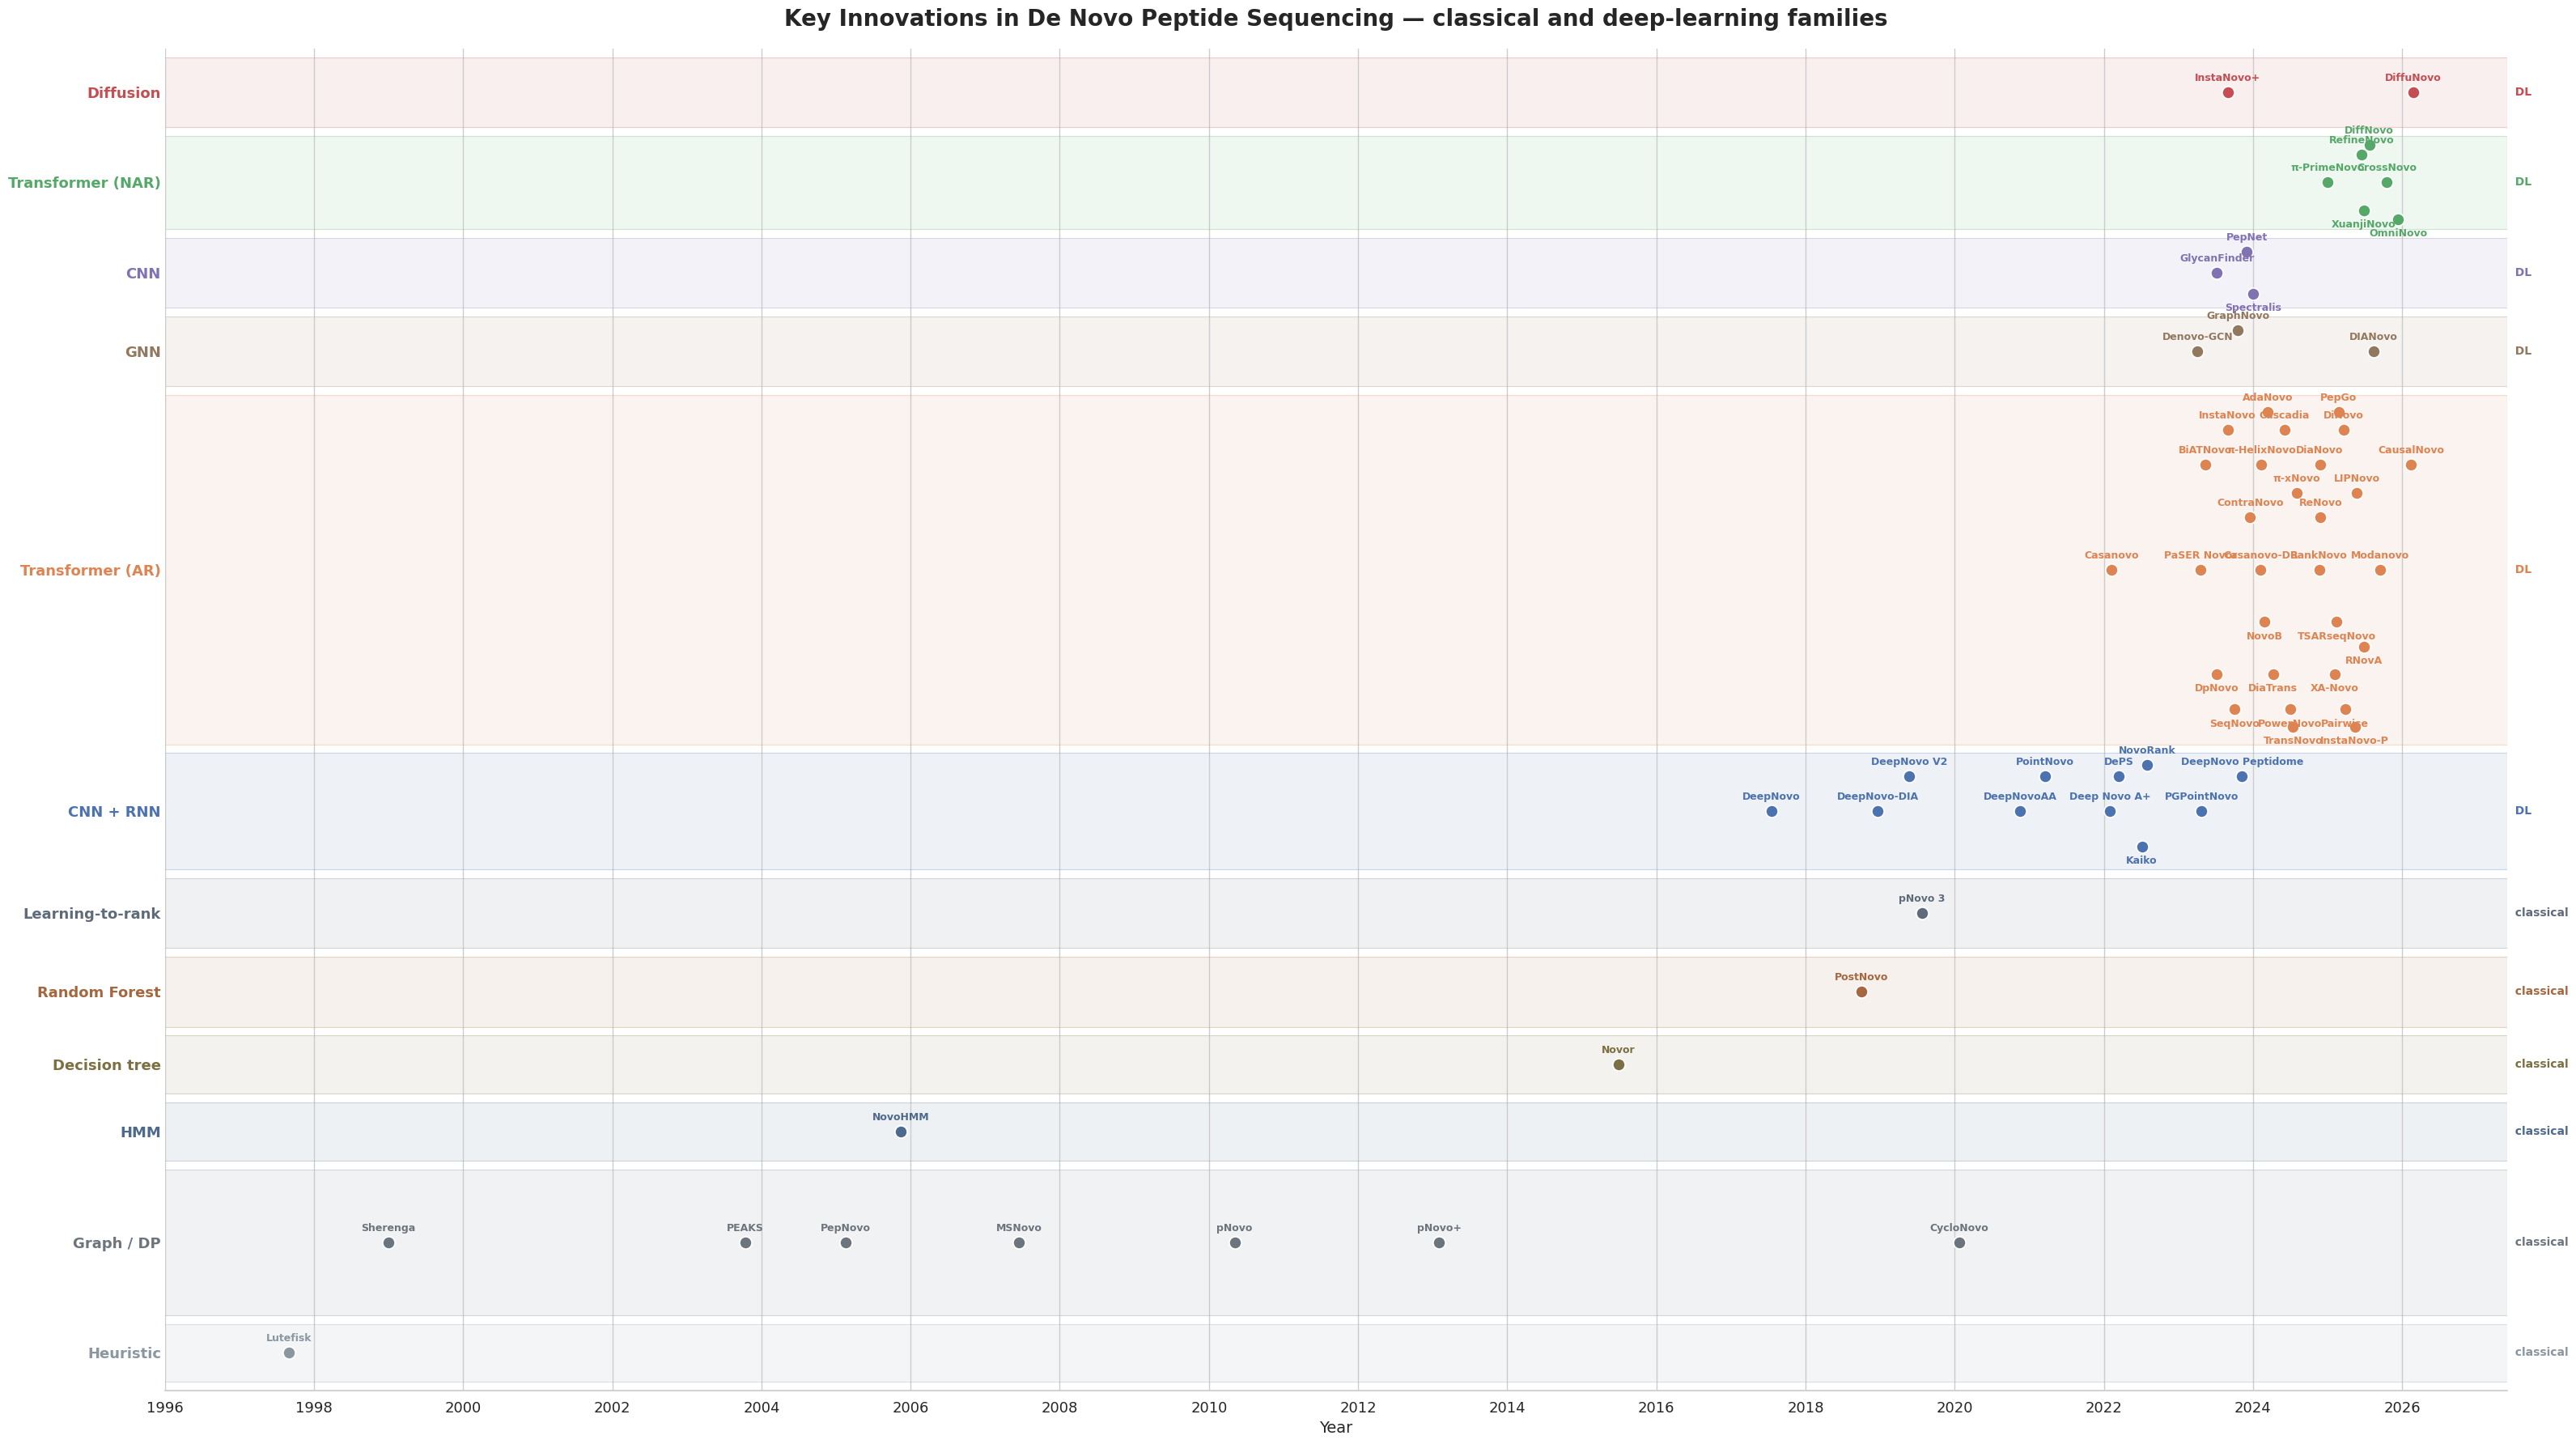

In [12]:
# Family bands: bottom-to-top = oldest paradigm to newest.
# (name, color, band_height, is_deep_learning)
band_defs = [
    ("Heuristic",         "#8a96a0", 1.0, 0),
    ("Graph / DP",        "#6c757d", 2.5, 0),
    ("HMM",               "#4d6a8c", 1.0, 0),
    ("Decision tree",     "#7b6f43", 1.0, 0),
    ("Random Forest",     "#a5673f", 1.2, 0),
    ("Learning-to-rank",  "#5f6b7a", 1.2, 0),
    ("CNN + RNN",         "#4C72B0", 2.0, 1),
    ("Transformer (AR)",  "#DD8452", 6.0, 1),
    ("GNN",               "#937860", 1.2, 1),
    ("CNN",               "#8172B3", 1.2, 1),
    ("Transformer (NAR)", "#55A868", 1.6, 1),
    ("Diffusion",         "#C44E52", 1.2, 1),
]

BAND_GAP = 0.15

bands = {}
y_cursor = 0
for name, color, height, is_dl in band_defs:
    bot = y_cursor
    top = y_cursor + height
    bands[name] = (bot, top, (bot + top) / 2, color, height, is_dl)
    y_cursor = top + BAND_GAP

# Pull innovations from the database — every algorithm with a family and a first publication.
df_innov = pd.read_sql("""
    SELECT a.name, a.algorithm_family, a.short_description, a.is_deep_learning,
           a.kind, a.acquisition_mode,
           MIN(p.publication_date) AS first_pub
    FROM algorithm a
    JOIN publication_algorithm pa ON a.id = pa.algorithm_id
    JOIN publication p ON pa.publication_id = p.id
    WHERE a.algorithm_family IS NOT NULL
      AND p.publication_date IS NOT NULL
    GROUP BY a.id
    ORDER BY first_pub
""", conn)
df_innov["first_pub"] = pd.to_datetime(df_innov["first_pub"])

# Tier slots interleave above and below the band center; min-gap of 270 days
# matches the Quarto site so long labels (e.g. "DeepNovo Peptidome") don't collide.
Y_TIERS = [0.5, 0.8, 0.2, 0.9, 0.1, 0.65, 0.35, 0.95, 0.05, 0.72, 0.28, 0.85, 0.15, 0.58, 0.42]
MIN_GAP_DAYS = 270

items = []
last_date_at_tier = {}
for _, row in df_innov.iterrows():
    fam = row["algorithm_family"]
    if fam not in bands:
        continue
    date = row["first_pub"]
    placed = False
    for tier_idx, y_frac in enumerate(Y_TIERS):
        key = (fam, tier_idx)
        if key not in last_date_at_tier or (date - last_date_at_tier[key]).days >= MIN_GAP_DAYS:
            last_date_at_tier[key] = date
            items.append((date, row["name"], row["short_description"], fam, y_frac))
            placed = True
            break
    if not placed:
        last_date_at_tier[(fam, 0)] = date
        items.append((date, row["name"], row["short_description"], fam, 0.5))

fig, ax = plt.subplots(figsize=(32, 18))

for bname, (bot, top, center, color, bh, is_dl) in bands.items():
    ax.axhspan(bot, top, color=color, alpha=0.09, zorder=0)
    ax.axhline(bot, color=color, linewidth=0.5, alpha=0.25)
    ax.axhline(top, color=color, linewidth=0.5, alpha=0.25)

band_centers = [bands[n][2] for n, _, _, _ in band_defs]
ax.set_yticks(band_centers)
ax.set_yticklabels([n for n, _, _, _ in band_defs], fontsize=13, fontweight="bold")
for lbl, (_, color, _, _) in zip(ax.get_yticklabels(), band_defs):
    lbl.set_color(color)

# Right-margin DL / classical annotation for each band.
x_min = pd.Timestamp("1996-01-01")
x_max = pd.Timestamp("2027-06-01")
for bname, (bot, top, center, color, bh, is_dl) in bands.items():
    tag = "DL" if is_dl else "classical"
    ax.text(x_max, center, f"  {tag}", va="center", ha="left",
            fontsize=10, color=color, fontweight="bold")

for date, name, desc, arch, y_frac in items:
    bot, top, center, color, bh, is_dl = bands[arch]
    y = bot + y_frac * bh

    ax.plot(date, y, "o", color=color, markersize=11, zorder=4,
            markeredgecolor="white", markeredgewidth=1.3)

    va = "bottom" if y_frac >= 0.5 else "top"
    y_off = 8 if y_frac >= 0.5 else -8

    ax.annotate(name, xy=(date, y), xytext=(0, y_off),
                textcoords="offset points",
                fontsize=9, fontweight="bold", va=va, ha="center",
                color=color, zorder=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlim(x_min, x_max)
total_h = sum(h for _, _, h, _ in band_defs) + BAND_GAP * (len(band_defs) - 1)
ax.set_ylim(-0.15, total_h + 0.15)
ax.set_xlabel("Year", fontsize=14)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", length=0)
ax.set_title("Key Innovations in De Novo Peptide Sequencing — classical and deep-learning families",
             fontsize=20, fontweight="bold", pad=20)
ax.yaxis.grid(False)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("plots/innovations_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Co-authorship Network

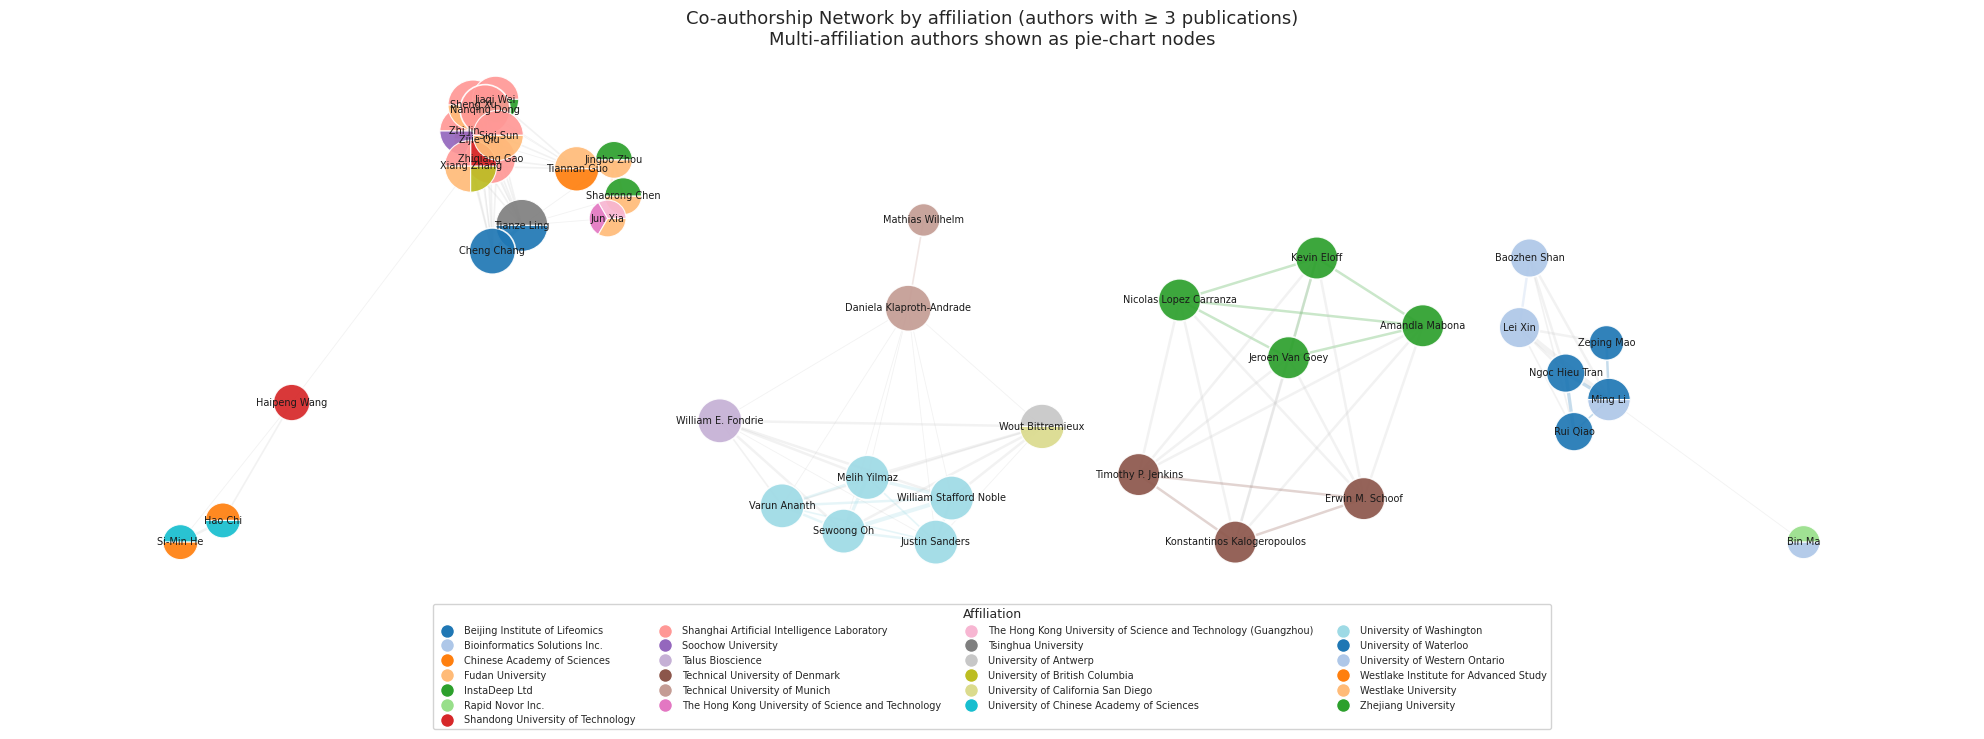

Network: 40 authors (16 with multiple affiliations), 123 co-authorship links
  Intra-affiliation edges: 57  |  Inter-affiliation edges: 66


In [13]:
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.patches import Wedge
import numpy as np

df_coauth = pd.read_sql("""
    SELECT pa1.author_id as a1, pa2.author_id as a2, COUNT(*) as weight
    FROM publication_author pa1
    JOIN publication_author pa2 ON pa1.publication_id = pa2.publication_id
    WHERE pa1.author_id < pa2.author_id
    GROUP BY pa1.author_id, pa2.author_id
""", conn)

author_names = dict(pd.read_sql("SELECT id, name FROM author", conn).values)

G = nx.Graph()
for _, row in df_coauth.iterrows():
    n1, n2 = author_names[row["a1"]], author_names[row["a2"]]
    G.add_edge(n1, n2, weight=row["weight"])

prolific = {r[0] for r in pd.read_sql("""
    SELECT a.name FROM author a
    JOIN publication_author pa ON a.id = pa.author_id
    GROUP BY a.id HAVING COUNT(*) >= 3
""", conn).values}

G_sub = G.subgraph([n for n in G.nodes if n in prolific]).copy()

# --- Collect ALL affiliations per author ---
df_author_aff = pd.read_sql("""
    SELECT a.name as author_name, aff.name as affiliation
    FROM author a
    JOIN author_affiliation aa ON a.id = aa.author_id
    JOIN affiliation aff ON aa.affiliation_id = aff.id
    GROUP BY a.id, aff.id
""", conn)

author_all_affs = {}
for name in G_sub.nodes:
    affs = list(df_author_aff[df_author_aff["author_name"] == name]["affiliation"].unique())
    author_all_affs[name] = affs if affs else ["Unknown"]

# Primary affiliation = the one shared with most co-authors (for layout grouping)
author_primary_aff = {}
for name in G_sub.nodes:
    affs = author_all_affs[name]
    if len(affs) == 1:
        author_primary_aff[name] = affs[0]
    else:
        neighbors = list(G_sub.neighbors(name))
        best_aff, best_count = affs[0], 0
        for aff in affs:
            count = sum(1 for nb in neighbors if aff in author_all_affs.get(nb, []))
            if count > best_count:
                best_aff, best_count = aff, count
        author_primary_aff[name] = best_aff

# Colour map over all affiliations that appear
all_affs_flat = set()
for affs in author_all_affs.values():
    all_affs_flat.update(affs)
unique_affs = sorted(all_affs_flat)
palette = sns.color_palette("tab20", n_colors=len(unique_affs))
aff_color_map = dict(zip(unique_affs, palette))

# --- Layout each connected component separately, then pack together ---
components = sorted(nx.connected_components(G_sub), key=len, reverse=True)

pos = {}
GAP = 0.15
cursor_x = 0.0

for comp_nodes in components:
    comp = G_sub.subgraph(comp_nodes).copy()

    # Affiliation-aware layout within the component
    G_layout = comp.copy()
    for name in comp.nodes:
        aff = author_primary_aff[name]
        for other in comp.nodes:
            if other != name and author_primary_aff[other] == aff:
                if G_layout.has_edge(name, other):
                    G_layout[name][other]["weight"] += 8
                else:
                    G_layout.add_edge(name, other, weight=8)

    comp_pos = nx.spring_layout(G_layout, k=0.8, seed=42, iterations=200, weight="weight")

    # Normalise to unit bounding box
    xs = [p[0] for p in comp_pos.values()]
    ys = [p[1] for p in comp_pos.values()]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_span = max(x_max - x_min, 1e-6)
    y_span = max(y_max - y_min, 1e-6)
    scale = np.sqrt(len(comp_nodes)) / 6.0

    for name in comp_pos:
        nx_ = (comp_pos[name][0] - x_min) / x_span * scale + cursor_x
        ny_ = (comp_pos[name][1] - y_min) / y_span * scale
        pos[name] = np.array([nx_, ny_])

    cursor_x += scale + GAP

# Centre vertically
all_ys = [p[1] for p in pos.values()]
y_mid = (max(all_ys) + min(all_ys)) / 2
for name in pos:
    pos[name][1] -= y_mid

degrees = dict(G_sub.degree())
edges = list(G_sub.edges(data=True))
edge_weights = [e[2]["weight"] for e in edges]

edge_colors = []
for u, v, d in edges:
    if author_primary_aff[u] == author_primary_aff[v]:
        edge_colors.append(aff_color_map[author_primary_aff[u]])
    else:
        edge_colors.append("#cccccc")

fig, ax = plt.subplots(figsize=(20, 10))

nx.draw_networkx_edges(G_sub, pos, alpha=0.25,
                       width=[w * 0.6 for w in edge_weights],
                       edge_color=edge_colors, ax=ax)

# Draw nodes: pie-chart wedges for multi-affiliation authors
x_all = [p[0] for p in pos.values()]
x_range = max(x_all) - min(x_all)
BASE_RADIUS = x_range * 0.016

for name in G_sub.nodes:
    x, y = pos[name]
    affs = author_all_affs[name]
    r = BASE_RADIUS * (0.6 + 0.4 * degrees[name] / max(degrees.values()))
    if len(affs) == 1:
        circle = plt.Circle((x, y), r, fc=aff_color_map[affs[0]],
                             ec="white", lw=1.2, alpha=0.92, zorder=3)
        ax.add_patch(circle)
    else:
        angle_per = 360.0 / len(affs)
        for i, aff in enumerate(affs):
            wedge = Wedge((x, y), r, i * angle_per, (i + 1) * angle_per,
                          fc=aff_color_map[aff], ec="white", lw=0.8,
                          alpha=0.92, zorder=3)
            ax.add_patch(wedge)

nx.draw_networkx_labels(G_sub, pos, font_size=7, ax=ax)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=aff_color_map[a],
           markersize=10, label=a)
    for a in unique_affs
]
ax.legend(handles=legend_elements, loc="upper center", fontsize=7,
          title="Affiliation", title_fontsize=9,
          framealpha=0.85, ncol=4,
          bbox_to_anchor=(0.5, -0.02))

ax.set_title("Co-authorship Network by affiliation (authors with ≥ 3 publications)\n"
             "Multi-affiliation authors shown as pie-chart nodes",
             fontsize=13)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("plots/coauthorship_network_affiliations.png", dpi=150, bbox_inches="tight")
plt.show()

multi = sum(1 for a in author_all_affs.values() if len(a) > 1)
intra = sum(1 for u, v, _ in edges if author_primary_aff[u] == author_primary_aff[v])
inter = sum(1 for u, v, _ in edges if author_primary_aff[u] != author_primary_aff[v])
print(f"Network: {G_sub.number_of_nodes()} authors ({multi} with multiple affiliations), "
      f"{G_sub.number_of_edges()} co-authorship links")
print(f"  Intra-affiliation edges: {intra}  |  Inter-affiliation edges: {inter}")

## 10. Algorithm Timeline

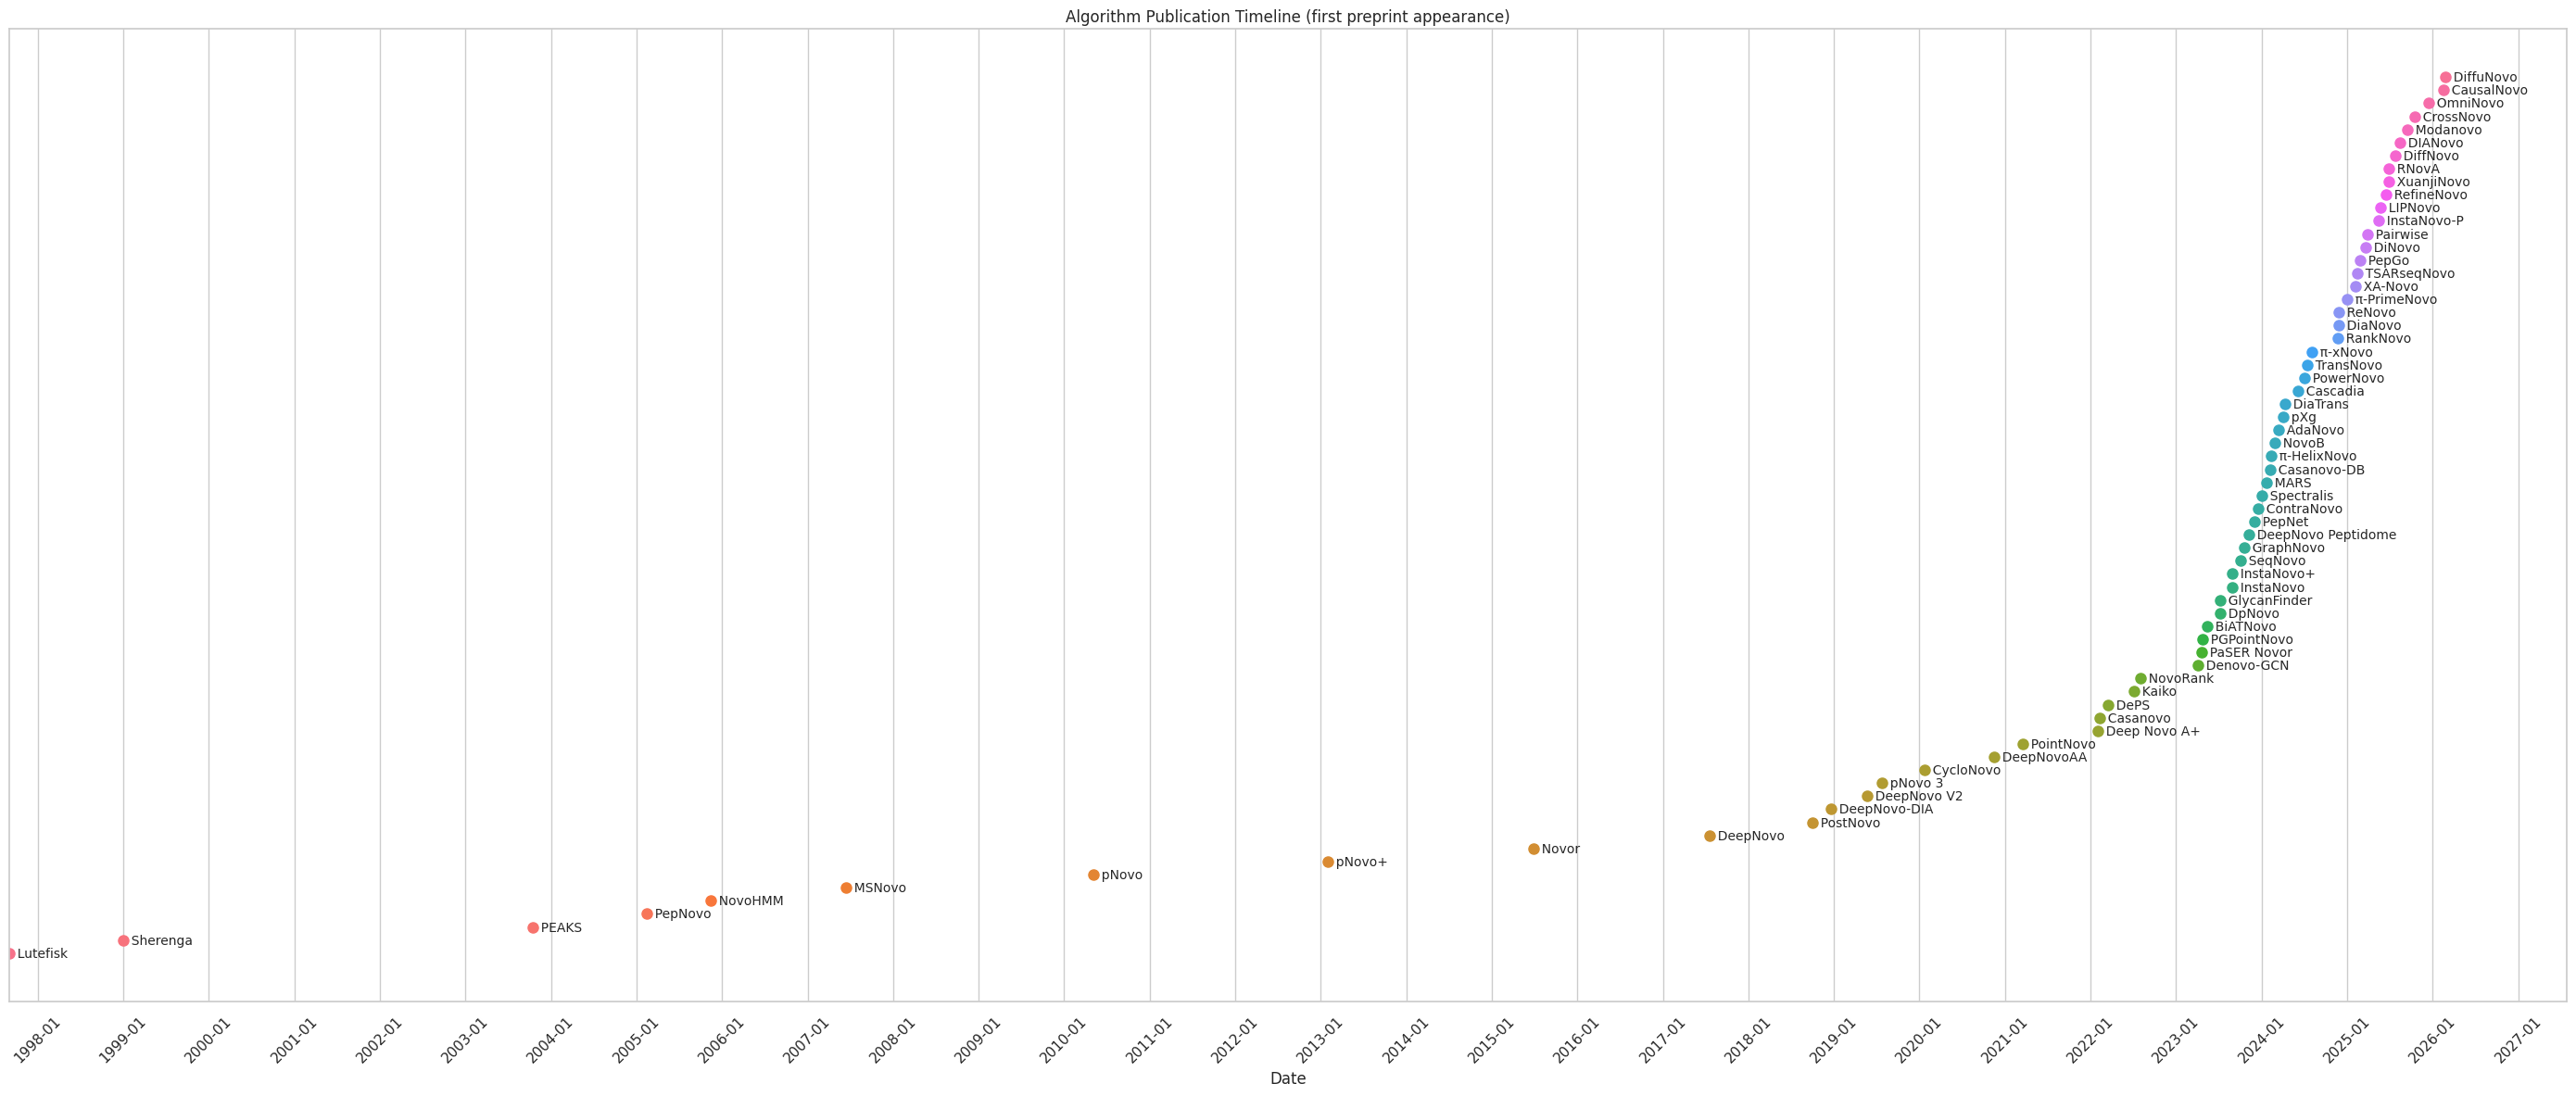

In [14]:
df_alg_timeline = pd.read_sql("""
    SELECT a.name as algorithm, MIN(p.publication_date) as first_pub
    FROM algorithm a
    JOIN publication_algorithm pa ON a.id = pa.algorithm_id
    JOIN publication p ON pa.publication_id = p.id
    WHERE p.publication_date IS NOT NULL
    GROUP BY a.id
    ORDER BY first_pub
""", conn)
df_alg_timeline["first_pub"] = pd.to_datetime(df_alg_timeline["first_pub"])

fig, ax = plt.subplots(figsize=(28, 12))
y_pos = range(len(df_alg_timeline))
colors = sns.color_palette("husl", len(df_alg_timeline))

ax.barh(y_pos, [1]*len(df_alg_timeline), left=mdates.date2num(df_alg_timeline["first_pub"]),
        height=0.6, color=colors, alpha=0)

for i, (_, row) in enumerate(df_alg_timeline.iterrows()):
    ax.plot(row["first_pub"], i, "o", color=colors[i], markersize=8)
    ax.text(row["first_pub"], i, f"  {row['algorithm']}", va="center", fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_yticks([])
ax.set_title("Algorithm Publication Timeline (first preprint appearance)")
ax.set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/publication_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Journals / Venues

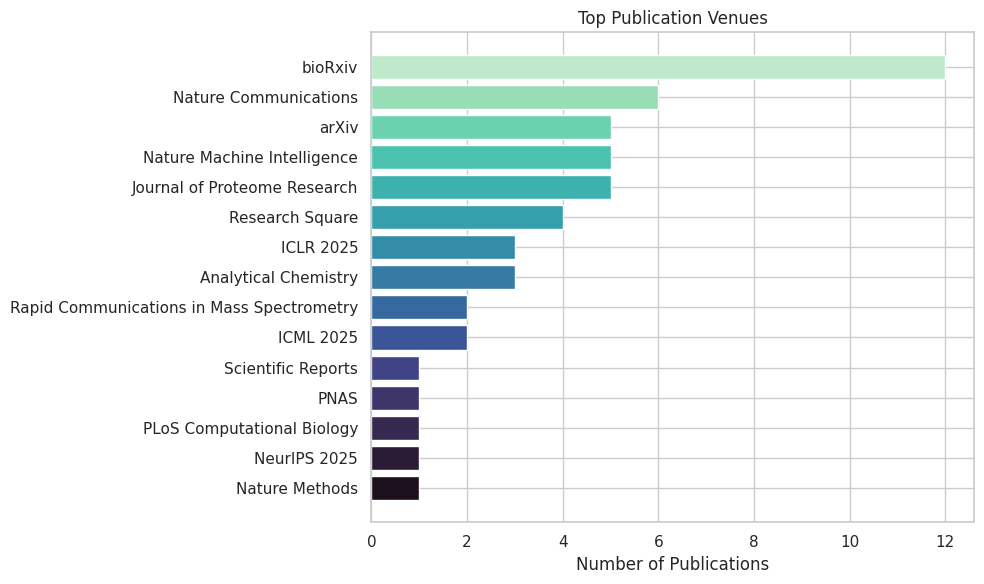

In [15]:
df_journals = pd.read_sql("""
    SELECT journal, COUNT(*) as cnt
    FROM publication
    WHERE journal IS NOT NULL
    GROUP BY journal
    ORDER BY cnt DESC
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
top_journals = df_journals.head(15)
ax.barh(top_journals["journal"][::-1], top_journals["cnt"][::-1],
        color=sns.color_palette("mako", len(top_journals)))
ax.set_xlabel("Number of Publications")
ax.set_title("Top Publication Venues")
plt.tight_layout()
plt.savefig("plots/top_venues.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Custom Queries

Use the cell below to run custom SQL queries against the database.

In [16]:
# Example: find all publications by a specific author
pd.read_sql("""
    SELECT p.title, p.publication_date, a2.name as algorithm
    FROM author a
    JOIN publication_author pa ON a.id = pa.author_id
    JOIN publication p ON pa.publication_id = p.id
    LEFT JOIN publication_algorithm pal ON p.id = pal.publication_id
    LEFT JOIN algorithm a2 ON pal.algorithm_id = a2.id
    WHERE a.name = 'Siqi Sun'
    ORDER BY p.publication_date DESC
""", conn)

,title,publication_date,algorithm
0,Accurate de novo sequencing of the modified pr...,2025-12-13,OmniNovo
1,Bidirectional Representations Augmented Autore...,2025-10-17,CrossNovo
2,MassNet: billion-scale AI-friendly mass spectr...,2025-06-26,XuanjiNovo
3,Curriculum Learning for Biological Sequence Pr...,2025-06-16,RefineNovo
4,Distilling Non-Autoregressive Model Knowledge ...,2025-02-05,XA-Novo
5,π-PrimeNovo: an accurate and efficient non-aut...,2025-01-02,π-PrimeNovo
6,RankNovo: A Universal Reranking Approach for R...,2024-11-20,RankNovo
7,ContraNovo: A Contrastive Learning Approach to...,2023-12-18,ContraNovo


In [17]:
# Example: find all affiliations for an author
pd.read_sql("""
    SELECT a.name as author, af.name as institution, af.department, c.name as country
    FROM author a
    JOIN author_affiliation aa ON a.id = aa.author_id
    JOIN affiliation af ON aa.affiliation_id = af.id
    JOIN country c ON af.country_id = c.id
    WHERE a.name = 'Xiang Zhang'
""", conn)

,author,institution,department,country
0,Xiang Zhang,University of British Columbia,Department of Computer Science,Canada
1,Xiang Zhang,Fudan University,Research Institute of Intelligent Complex Systems,China
2,Xiang Zhang,Shanghai Artificial Intelligence Laboratory,NaN,China
3,Xiang Zhang,Shandong University of Technology,School of Computer Science and Technology,China


In [18]:
conn.close()